In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
import scipy.cluster.hierarchy as shc
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV
from sklearn import metrics

%matplotlib inline

# define data

### normalized data

In [2]:
df_normalized = pd.read_csv('data/baasta-data-joncannon_outlier_rejected_normalized.csv')

In [3]:
df_normalized['Paced_music_mean_CV_iti'] = np.mean(df_normalized[['Paced_music_badine_mean_CV_iti', 'Paced_music_ross_mean_CV_iti']])

In [4]:
fiveash_columns = [
    'BAT_all_dprime',
    'Anisochrony_tones_threshold',
    'Unpaced_spontaneous_right_CV_iti',
    'SyncCont_metro_600_mean_CV_iti',
    'Paced_metro_600_mean_CV_iti',
]
#     'Paced_music_mean_CV_iti',


df_normalized_fivash = df_normalized[fiveash_columns]

### tSNE data

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is de

<AxesSubplot: >

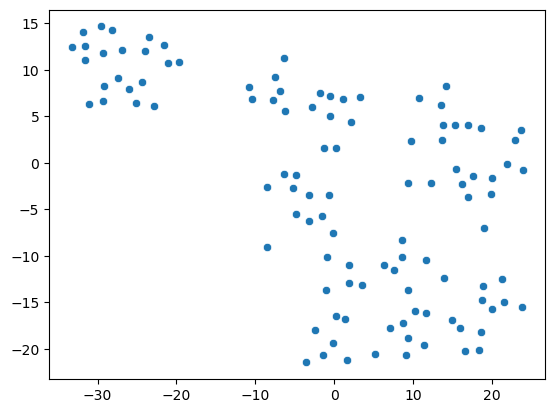

In [5]:
tsne_norm = TSNE(n_components=2, learning_rate='auto',init='random', perplexity=10)
tsne_normalized_data = tsne_norm.fit_transform(df_normalized.iloc[:,2:])
sns.scatterplot(x=tsne_normalized_data[:,0], y=tsne_normalized_data[:,1])

### PCA data

/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if not hasattr(array, "sparse") and array.dtypes.apply(is_sparse).any():
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/Users/matin/miniconda3/envs/phd_codes/lib/python3.11/site-packages/sklearn/utils/validation.py:767: FutureWarning: is_sparse is deprec

<AxesSubplot: >

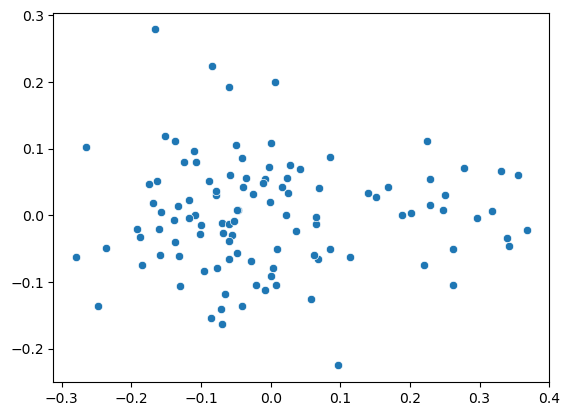

In [6]:
pca_norm = PCA(n_components=2)
pca_norm.fit(df_normalized.iloc[:,2:])
pca_normalized_data = pca_norm.transform(X=df_normalized.iloc[:,2:])
sns.scatterplot(x=pca_normalized_data[:,0], y=pca_normalized_data[:,1])

### synthetic data

In [6]:
n_samples = 500
np.random.seed(0)
C = np.array([[0.0, -0.1], [1.7, 0.4]])
component_1 = np.dot(np.random.randn(n_samples, 2), C)  # general
component_2 = 0.7 * np.random.randn(n_samples, 2) + np.array([-4, 1])  # spherical
synthetic_X = np.concatenate([component_1, component_2])

### define X

In [7]:
# X = tsne_normalized_data
# X = pca_normalized_data
X = df_normalized.iloc[:,2:]
# X = synthetic_X

# BIC method

## define score 

In [8]:
def gmm_bic_score(estimator, X):
    return -estimator.bic(X)

## define grid search

In [9]:
param_grid = {
    "n_components": range(1, 7),
    "covariance_type": ["spherical", "tied", "diag", "full"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_bic_score
)

## fit grid search

In [10]:
grid_search.fit(X)

GridSearchCV(estimator=GaussianMixture(),
             param_grid={'covariance_type': ['spherical', 'tied', 'diag',
                                             'full'],
                         'n_components': range(1, 7)},
             scoring=<function gmm_bic_score at 0x7f5be08ca440>)

## show dataframe of results

In [11]:
df = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df["mean_test_score"] = -df["mean_test_score"]
df = df.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "BIC score",
    }
)
df.sort_values(by="BIC score").head()

,Number of components,Type of covariance,BIC score
12,1,diag,-10962.730732
13,2,diag,-10693.191761
14,3,diag,-10394.249039
15,4,diag,-10043.336723
16,5,diag,-9692.064717


## plot the results

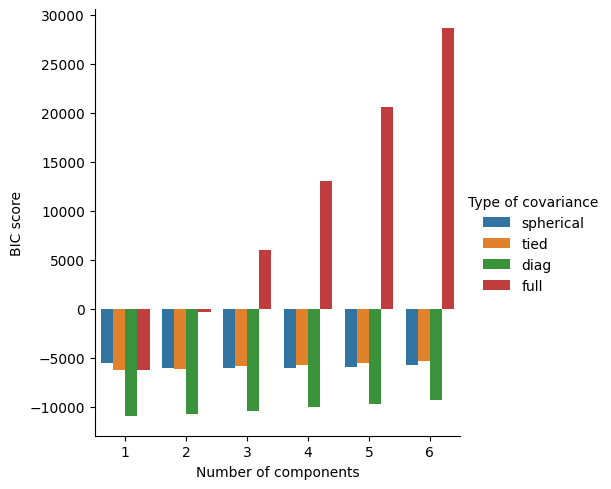

In [12]:
sns.catplot(
    data=df,
    kind="bar",
    x="Number of components",
    y="BIC score",
    hue="Type of covariance",
)
plt.show()

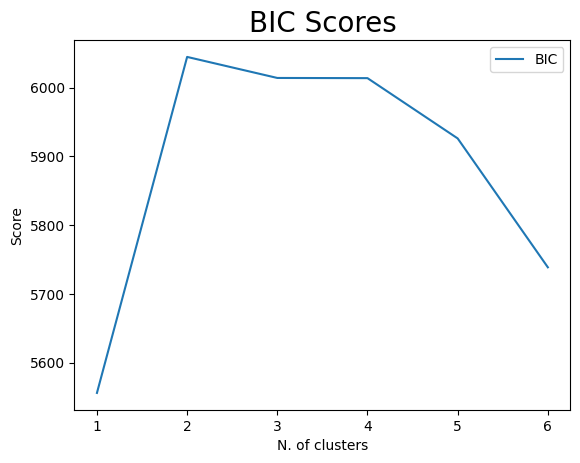

In [13]:
bics_err = -df[df['Type of covariance'] == 'spherical']['BIC score']
n_clusters = np.arange(1,7)
plt.plot(n_clusters,bics_err, label='BIC')
plt.title("BIC Scores", fontsize=20)
plt.xticks(n_clusters)
plt.xlabel("N. of clusters")
plt.ylabel("Score")
plt.legend()

# Silohuette coefficient

## define score 

In [162]:
def gmm_silohuette_score(estimator, X):
    labels=estimator.predict(X)
#     print('here labels:', len(labels), '\n', labels)
    sil=metrics.silhouette_score(X, labels, metric='euclidean')
    return sil

## define grid search

In [163]:
param_grid = {
    "n_components": range(2, 7),
    "covariance_type": ["spherical", "tied", "diag", "full"],
}
grid_search = GridSearchCV(
    GaussianMixture(), param_grid=param_grid, scoring=gmm_silohuette_score
)

## fit grid search

In [165]:
grid_search.fit(X)

GridSearchCV(estimator=GaussianMixture(),
             param_grid={'covariance_type': ['spherical', 'tied', 'diag',
                                             'full'],
                         'n_components': range(2, 7)},
             scoring=<function gmm_silohuette_score at 0x7fd7da400ee0>)

## show dataframe of results

In [166]:
df = pd.DataFrame(grid_search.cv_results_)[
    ["param_n_components", "param_covariance_type", "mean_test_score"]
]
df = df.rename(
    columns={
        "param_n_components": "Number of components",
        "param_covariance_type": "Type of covariance",
        "mean_test_score": "Silohuette score",
    }
)
df.sort_values(by="Silohuette score").tail()

,Number of components,Type of covariance,Silohuette score
1,3,spherical,0.198281
15,2,full,0.315513
10,2,diag,0.335274
5,2,tied,0.399348
0,2,spherical,0.424408


## plot the results

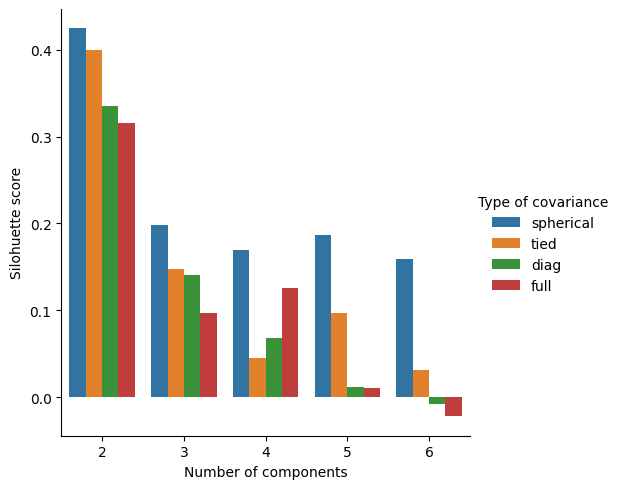

In [167]:
sns.catplot(
    data=df,
    kind="bar",
    x="Number of components",
    y="Silohuette score",
    hue="Type of covariance",
)
plt.show()

# PCA results BIC Original

In [15]:
pca_n_components = range(2, 60)
gmm_n_components = range(1, 7)
gmm_covariance = ["spherical", "tied", "diag", "full"]
results = {'pca_n_components':[], 'gmm_n_components':[], 'gmm_covariance':[], 'test_score':[]}
X = df_normalized.iloc[:,2:]
for pca_n in pca_n_components:
    for gmm_n in gmm_n_components:
        for c_type in gmm_covariance:
            pca = PCA(n_components=pca_n)
            pca.fit(X)
            x_pca = pca.transform(X)
            gmm=GaussianMixture(n_components=gmm_n, covariance_type=c_type).fit(x_pca) 
            test_score = gmm.bic(x_pca)
            results['pca_n_components'].append(pca_n)
            results['gmm_n_components'].append(gmm_n)
            results['gmm_covariance'].append(c_type)
            results['test_score'].append(test_score)

            
df_result = pd.DataFrame(results)[["pca_n_components", "gmm_n_components", "gmm_covariance", "test_score"]]            

In [43]:
df_result.sort_values(by='test_score')

,pca_n_components,gmm_n_components,gmm_covariance,test_score
1370,59,1,diag,-61064.764392
1374,59,2,diag,-60758.298431
1378,59,3,diag,-60269.237215
1382,59,4,diag,-59824.106799
1346,58,1,diag,-59780.544237
...,...,...,...,...
15,2,4,full,-274.305232
18,2,5,diag,-270.477193
19,2,5,full,-257.313042
22,2,6,diag,-253.999947


In [57]:
gmm_two_works = []

for pca_n in pca_n_components:
    for c_type in gmm_covariance:
        temp_df = df_result[(df_result['gmm_covariance']==c_type) & (df_result['pca_n_components']==pca_n)]
        if temp_df.sort_values(by='test_score')['gmm_n_components'].values[0] == 1:
            value = temp_df[temp_df['gmm_n_components']==1]['test_score']
            gmm_two_works.append(f'{str(pca_n)} with {str(c_type)} works with value {value.values[0]}' )

gmm_two_works

['4 with full works with value -933.9383101639544',
 '5 with full works with value -1428.0807276599303',
 '6 with diag works with value -2015.3243941854314',
 '6 with full works with value -1945.092425778568',
 '8 with diag works with value -3205.420735963401',
 '9 with diag works with value -3832.8181558559218',
 '10 with diag works with value -4492.511596731005',
 '10 with full works with value -4281.815691510417',
 '11 with diag works with value -5174.884189039835',
 '11 with full works with value -4917.366971548003',
 '12 with diag works with value -5895.627255181319',
 '12 with full works with value -5586.606594191121',
 '13 with diag works with value -6642.231488611462',
 '13 with full works with value -6277.0252528957735',
 '14 with diag works with value -7416.507004462525',
 '14 with full works with value -6990.433062794221',
 '15 with diag works with value -8204.515263029094',
 '15 with full works with value -7712.891484181051',
 '16 with diag works with value -9004.2027895234

In [50]:
df_result[(df_result['gmm_covariance']=='spherical') & (df_result['pca_n_components']==59)].sort_values(by='test_score')

,pca_n_components,gmm_n_components,gmm_covariance,test_score
1388,59,6,spherical,-34279.819287
1384,59,5,spherical,-34172.458371
1380,59,4,spherical,-33832.276453
1376,59,3,spherical,-32981.447373
1372,59,2,spherical,-32087.205831
1368,59,1,spherical,-28632.842451


# PCA results BIC Fivash

In [62]:
df_normalized_fivash.shape

(108, 5)

In [64]:
pca_n_components = range(2, 4)
gmm_n_components = range(1, 7)
gmm_covariance = ["spherical", "tied", "diag", "full"]
results = {'pca_n_components':[], 'gmm_n_components':[], 'gmm_covariance':[], 'test_score':[]}
X = df_normalized_fivash.iloc[:,2:]
for pca_n in pca_n_components:
    for gmm_n in gmm_n_components:
        for c_type in gmm_covariance:
            pca = PCA(n_components=pca_n)
            pca.fit(X)
            x_pca = pca.transform(X)
            gmm=GaussianMixture(n_components=gmm_n, covariance_type=c_type).fit(x_pca) 
            test_score = gmm.bic(x_pca)
            results['pca_n_components'].append(pca_n)
            results['gmm_n_components'].append(gmm_n)
            results['gmm_covariance'].append(c_type)
            results['test_score'].append(test_score)

            
df_result = pd.DataFrame(results)[["pca_n_components", "gmm_n_components", "gmm_covariance", "test_score"]]            

In [73]:
df_result

,pca_n_components,gmm_n_components,gmm_covariance,test_score
0,2,1,spherical,-2573.073104
1,2,1,tied,-2563.708844
2,2,1,diag,-2568.390975
3,2,1,full,-2563.708844
4,2,2,spherical,-2554.344579
5,2,2,tied,-2549.662450
6,2,2,diag,-2544.980319
7,2,2,full,-2535.616056
8,2,3,spherical,-2535.616054
9,2,3,tied,-2535.616056


In [72]:
gmm_two_works = []

for pca_n in pca_n_components:
    for c_type in gmm_covariance:
        temp_df = df_result[(df_result['gmm_covariance']==c_type) & (df_result['pca_n_components']==pca_n)]
        if temp_df.sort_values(by='test_score')['gmm_n_components'].values[0] == 1:
            value = temp_df[temp_df['gmm_n_components']==1]['test_score']
            gmm_two_works.append(f'{str(pca_n)} with {str(c_type)} works with value {value.values[0]}' )

gmm_two_works

['2 with spherical works with value -2573.0731042863767',
 '2 with tied works with value -2563.7088435379255',
 '2 with diag works with value -2568.3909747650496',
 '2 with full works with value -2563.7088435379255',
 '3 with spherical works with value -3861.9728474151607',
 '3 with tied works with value -3838.562194118636',
 '3 with diag works with value -3852.6085878000085',
 '3 with full works with value -3838.562194118636']

In [50]:
df_result[(df_result['gmm_covariance']=='spherical') & (df_result['pca_n_components']==59)].sort_values(by='test_score')

,pca_n_components,gmm_n_components,gmm_covariance,test_score
1388,59,6,spherical,-34279.819287
1384,59,5,spherical,-34172.458371
1380,59,4,spherical,-33832.276453
1376,59,3,spherical,-32981.447373
1372,59,2,spherical,-32087.205831
1368,59,1,spherical,-28632.842451
